In [87]:
import numpy as np
import pandas as pd
import requests
import datetime

In [89]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [562]:
l_url = "https://api.spacexdata.com/v4/launchpads/"
p_url = 'https://api.spacexdata.com/v4/payloads/'
r_url = 'https://api.spacexdata.com/v4/rockets/'
c_url = 'https://api.spacexdata.com/v4/cores/'

In [564]:
def getBoosterVersion(data):
    for x in data['rocket']:
        if x:
            response = requests.get((r_url+str(x))).json()
            BoosterVersion.append(response['name'])
        

In [566]:
def getLaunchPad(data):
    for x in data['launchpad']:
        if x:
            response = requests.get("https://api.spacexdata.com/v4/launchpads/"+str(x)).json()
            Longitude.append(response['longitude'])
            Latitude.append(response['latitude'])
            LaunchSite.append(response['name'])

In [568]:
def getPayloadData(data):
    for load in data['payloads']:
       if load:
        response = requests.get(p_url+load).json()
        PayloadMass.append(response['mass_kg'])
        Orbit.append(response['orbit'])

In [570]:
def getCoreData(data):
    for core in data['cores']:
            if core['core'] != None:
                response = requests.get(c_url+core['core']).json()
                Block.append(response['block'])
                ReusedCount.append(response['reuse_count'])
                Serial.append(response['serial'])
            else:
                Block.append(None)
                ReusedCount.append(None)
                Serial.append(None)
            Outcome.append(str(core['landing_success'])+' '+str(core['landing_type']))
            Flights.append(core['flight'])
            GridFins.append(core['gridfins'])
            Reused.append(core['reused'])
            Legs.append(core['legs'])
            LandingPad.append(core['landpad'])

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/lab_v2/images/landing_1.gif)

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/lab_v2/images/crash.gif)

In [584]:
#url = 'https://api.spacexdata.com/v4/launches/past'

static_json_url='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json'

response = requests.get(static_json_url)

data = pd.json_normalize(response.json())

In [585]:
data

,static_fire_date_utc,static_fire_date_unix,tbd,net,window,rocket,success,details,crew,ships,capsules,payloads,launchpad,auto_update,failures,flight_number,name,date_utc,date_unix,date_local,date_precision,upcoming,cores,id,fairings.reused,fairings.recovery_attempt,fairings.recovered,fairings.ships,links.patch.small,links.patch.large,links.reddit.campaign,links.reddit.launch,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Engine failure at 33 seconds and loss of vehicle,[],[],[],[5eb0e4b5b6c3bb0006eeb1e1],5e9e4502f5090995de566f86,True,"[{'time': 33, 'altitude': None, 'reason': 'merlin engine failure'}]",1,FalconSat,2006-03-24T22:30:00.000Z,1143239400,2006-03-25T10:30:00+12:00,hour,False,"[{'core': '5e9e289df35918033d3b2623', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cd9ffd86e000604b32a,False,False,False,[],https://images2.imgbox.com/3c/0e/T8iJcSN3_o.png,https://images2.imgbox.com/40/e3/GypSkayF_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html,https://en.wikipedia.org/wiki/DemoSat,NaN
1,None,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,"Successful first stage burn and transition to second stage, maximum altitude 289 km, Premature engine shutdown at T+7 min 30 s, Failed to reach orbit, Failed to recover first stage",[],[],[],[5eb0e4b6b6c3bb0006eeb1e2],5e9e4502f5090995de566f86,True,"[{'time': 301, 'altitude': 289, 'reason': 'harmonic oscillation leading to premature engine shutdown'}]",2,DemoSat,2007-03-21T01:10:00.000Z,1174439400,2007-03-21T13:10:00+12:00,hour,False,"[{'core': '5e9e289ef35918416a3b2624', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdaffd86e000604b32b,False,False,False,[],https://images2.imgbox.com/4f/e3/I0lkuJ2e_o.png,https://images2.imgbox.com/be/e7/iNqsqVYM_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-rocket-fails-reach-orbit.html,https://en.wikipedia.org/wiki/DemoSat,NaN
2,None,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Residual stage 1 thrust led to collision between stage 1 and stage 2,[],[],[],"[5eb0e4b6b6c3bb0006eeb1e3, 5eb0e4b6b6c3bb0006eeb1e4]",5e9e4502f5090995de566f86,True,"[{'time': 140, 'altitude': 35, 'reason': 'residual stage-1 thrust led to collision between stage 1 and stage 2'}]",3,Trailblazer,2008-08-03T03:34:00.000Z,1217734440,2008-08-03T15:34:00+12:00,hour,False,"[{'core': '5e9e289ef3591814873b2625', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdbffd86e000604b32c,False,False,False,[],https://images2.imgbox.com/3d/86/cnu0pan8_o.png,https://images2.imgbox.com/4b/bd/d8UxLh4q_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1-flight-3-mission-summary,https://en.wikipedia.org/wiki/Trailblazer_(satellite),NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,True,"Ratsat was carried to orbit on the first successful orbital launch of any privately funded and developed, liquid-propelled carrier rocket, the SpaceX Falcon 1",[],[],[],[5eb0e4b7b6c3bb0006eeb1e5],5e9e4502f5090995de566f86,True,[],4,RatSat,2008-09-28T23:15:00.000Z,1222643700,2008-09-28T11:15:00+12:00,hour,False,"[{'core': '5e9e289ef3591855dc3b2626', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_succes

In [575]:
data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]
data = data[data['cores'].map(len) == 1]
data = data[data['payloads'].map(len) == 1]

data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])


In [576]:
data['date'] = pd.to_datetime(data['date_utc']).dt.date

data = data[data['date'] <= datetime.date(2020, 11, 13)]

In [577]:
#Global variables 
BoosterVersion = []
PayloadMass = []
Orbit = []
LaunchSite = []
Outcome = []
Flights = []
GridFins = []
Reused = []
Legs = []
LandingPad = []
Block = []
ReusedCount = []
Serial = []
Longitude = []
Latitude = []

In [578]:
getBoosterVersion(data)

In [111]:
getLaunchPad(data)

In [114]:
getPayloadData(data)

In [115]:
getCoreData(data)

In [117]:
launch_dict = {'FlightNumber': list(data['flight_number']),
'Date': list(data['date']),
'BoosterVersion':BoosterVersion,
'PayloadMass':PayloadMass,
'Orbit':Orbit,
'LaunchSite':LaunchSite,
'Outcome':Outcome,
'Flights':Flights,
'GridFins':GridFins,
'Reused':Reused,
'Legs':Legs,
'LandingPad':LandingPad,
'Block':Block,
'ReusedCount':ReusedCount,
'Serial':Serial,
'Longitude': Longitude,
'Latitude': Latitude}

In [121]:
df = pd.DataFrame(launch_dict)

In [123]:
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2006-03-24,Falcon 1,20.0,LEO,Kwajalein Atoll,None None,1,False,False,False,None,NaN,0,Merlin1A,167.743129,9.047721
1,2,2007-03-21,Falcon 1,NaN,LEO,Kwajalein Atoll,None None,1,False,False,False,None,NaN,0,Merlin2A,167.743129,9.047721
2,4,2008-09-28,Falcon 1,165.0,LEO,Kwajalein Atoll,None None,1,False,False,False,None,NaN,0,Merlin2C,167.743129,9.047721
3,5,2009-07-13,Falcon 1,200.0,LEO,Kwajalein Atoll,None None,1,False,False,False,None,NaN,0,Merlin3C,167.743129,9.047721
4,6,2010-06-04,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0003,-80.577366,28.561857


In [155]:
df_falcon9 = df[df['BoosterVersion'] == 'Falcon 9']

In [157]:
df_falcon9

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
4,6,2010-06-04,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0003,-80.577366,28.561857
5,8,2012-05-22,Falcon 9,525.0,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0005,-80.577366,28.561857
6,10,2013-03-01,Falcon 9,677.0,ISS,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0007,-80.577366,28.561857
7,11,2013-09-29,Falcon 9,500.0,PO,VAFB SLC 4E,False Ocean,1,False,False,False,None,1.0,0,B1003,-120.610829,34.632093
8,12,2013-12-03,Falcon 9,3170.0,GTO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B1004,-80.577366,28.561857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,102,2020-09-03,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,2,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,12,B1060,-80.603956,28.608058
90,103,2020-10-06,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,3,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,13,B1058,-80.603956,28.608058
91,104,2020-10-18,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,6,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,12,B1051,-80.603956,28.608058
92,105,2020-10-24,Falcon 9,15600.0,VLEO,CCSFS SLC 40,True ASDS,3,True,True,True,5e9e3033383ecbb9e534e7cc,5.0,12,B1060,-80.577366,28.561857


In [159]:
df_falcon9.loc[:,'FlightNumber'] = list(range(1, df_falcon9.shape[0]+1))
df_falcon9

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
4,1,2010-06-04,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0003,-80.577366,28.561857
5,2,2012-05-22,Falcon 9,525.0,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0005,-80.577366,28.561857
6,3,2013-03-01,Falcon 9,677.0,ISS,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0007,-80.577366,28.561857
7,4,2013-09-29,Falcon 9,500.0,PO,VAFB SLC 4E,False Ocean,1,False,False,False,None,1.0,0,B1003,-120.610829,34.632093
8,5,2013-12-03,Falcon 9,3170.0,GTO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B1004,-80.577366,28.561857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,86,2020-09-03,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,2,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,12,B1060,-80.603956,28.608058
90,87,2020-10-06,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,3,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,13,B1058,-80.603956,28.608058
91,88,2020-10-18,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,6,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,12,B1051,-80.603956,28.608058
92,89,2020-10-24,Falcon 9,15600.0,VLEO,CCSFS SLC 40,True ASDS,3,True,True,True,5e9e3033383ecbb9e534e7cc,5.0,12,B1060,-80.577366,28.561857


In [161]:
df_falcon9.isnull().sum()

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        5
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64

In [163]:
df_falcon9['PayloadMass'].mean()

6123.547647058824

In [169]:
df_falcon9['PayloadMass'].replace(np.nan,df_falcon9['PayloadMass'].mean(), inplace=True)

/var/folders/6f/ll6v0vbn61l20zm5g3_z8xj40000gn/T/ipykernel_12202/4123084968.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_falcon9['PayloadMass'].replace(np.nan,df_falcon9['PayloadMass'].mean(), inplace=True)
/var/folders/6f/ll6v0vbn61l20zm5g3_z8xj40000gn/T/ipykernel_12202/4123084968.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  

In [171]:
df_falcon9['PayloadMass'].isnull().sum()

0

In [173]:
df_falcon9.to_csv('dataset_part_1.csv', index=False)

In [329]:
weather_url = "https://api.weatherstack.com/current?access_key="+ str(api_key)
api_key = "4eb88f04a69b81e54cd02291eafc8c47"
#querystring = {"query":"London"}
#querystring = {"query":"New York"}

In [331]:
#def getLocationWeather()

In [333]:
data = {
    'City': ['Riyadh', 'Jeddah', 'Mecca', 'Medina', 'Dammam', 'Khobar', 'Tabuk', 'Abha', 'Hofuf', 'Jubail'],
    'Region': ['Riyadh', 'Makkah', 'Makkah', 'Madinah', 'Eastern Province', 'Eastern Province', 'Tabuk', 'Asir', 'Eastern Province', 'Eastern Province']
}

# Convert the dictionary to a DataFrame
data = pd.DataFrame(data)



In [335]:
for x in data["City"]:
    querystring["querry"] = str(x)
    print(str(querystring))

{'query': 'New York', 'querry': 'Riyadh'}
{'query': 'New York', 'querry': 'Jeddah'}
{'query': 'New York', 'querry': 'Mecca'}
{'query': 'New York', 'querry': 'Medina'}
{'query': 'New York', 'querry': 'Dammam'}
{'query': 'New York', 'querry': 'Khobar'}
{'query': 'New York', 'querry': 'Tabuk'}
{'query': 'New York', 'querry': 'Abha'}
{'query': 'New York', 'querry': 'Hofuf'}
{'query': 'New York', 'querry': 'Jubail'}


In [313]:
querystring = {"query":"New York"}

{'query': 'New York'}

In [315]:
response = requests.get(url, params=querystring)

In [271]:
response = requests.get(weather_url, params=querystring).json()

In [273]:
pd.json_normalize(response)

,request.type,request.query,request.language,request.unit,location.name,location.country,location.region,location.lat,location.lon,location.timezone_id,location.localtime,location.localtime_epoch,location.utc_offset,current.observation_time,current.temperature,current.weather_code,current.weather_icons,current.weather_descriptions,current.wind_speed,current.wind_degree,current.wind_dir,current.pressure,current.precip,current.humidity,current.cloudcover,current.feelslike,current.uv_index,current.visibility,current.is_day
0,City,"New York, United States of America",en,m,New York,United States of America,New York,40.714,-74.006,America/New_York,2024-08-20 07:21,1724138460,-4.0,11:21 AM,17,122,[https://cdn.worldweatheronline.com/images/wsymbols01_png_64/wsymbol_0004_black_low_cloud.png],[Overcast],4,325,NW,1012,0,65,100,17,4,16,yes


![]![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_1_L2/images/falcon9-launches-wiki.png)

In [342]:
!pip3 install beautifulsoup4
!pip3 install requests

In [510]:
import sys

import requests
from bs4 import BeautifulSoup
import re
import unicodedata
import pandas as pd

In [524]:
def date_time(table_cells):
    """
    This function returns the data and time from the HTML  table cell
    Input: the  element of a table data cell extracts extra row
    """
    return [data_time.strip() for data_time in list(table_cells.strings)][0:2]

def booster_version(table_cells):
    """
    This function returns the booster version from the HTML  table cell 
    Input: the  element of a table data cell extracts extra row
    """
    out=''.join([booster_version for i,booster_version in enumerate( table_cells.strings) if i%2==0][0:-1])
    return out

def landing_status(table_cells):
    """
    This function returns the landing status from the HTML table cell 
    Input: the  element of a table data cell extracts extra row
    """
    out=[i for i in table_cells.strings][0]
    return out


def get_mass(table_cells):
    mass=unicodedata.normalize("NFKD", table_cells.text).strip()
    if mass:
        mass.find("kg")
        new_mass=mass[0:mass.find("kg")+2]
    else:
        new_mass=0
    return new_mass


# Define the function to extract column name from a <th> element
def extract_column_from_header(row):
    """
    This function returns the column name from the HTML <th> element.
    """
    if row.br:
        row.br.extract()
    if row.a:
        row.a.extract()
    if row.sup:
        row.sup.extract()
        
    # Convert the contents of <th> to a string and join them
    column_name = ' '.join([str(content).strip() if isinstance(content, str) else content.get_text(strip=True) for content in row.contents])
    
    # Filter out digits and empty names
    if not column_name.strip().isdigit() and column_name.strip():
        return column_name.strip()
    return None

In [526]:
static_url = "https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches&oldid=1027686922"

In [528]:
response = requests.get(static_url)

In [529]:
# Check if the request was successful
if response.status_code == 200:
    # Parse the HTML content using BeautifulSoup
    soup = BeautifulSoup(response.text, 'html.parser')

    # Example: Find and print the title of the webpage
    title = soup.title.string
    print(f"Title of the page: {title}")
else:
    print(f"Failed to retrieve the webpage. Status code: {response.status_code}")


Title of the page: List of Falcon 9 and Falcon Heavy launches - Wikipedia


In [530]:
html_tables = soup.find_all('table')

In [532]:
# Initialize an empty list to store column names
column_names = []

# Find the table by ID and get all <th> elements

th_elements = soup.find_all('th')

# Iterate over each <th> element, apply the function, and store non-empty names
for th in th_elements:
    name = extract_column_from_header(th)
    if name is not None and len(name) > 0:
        column_names.append(name)

# Print the list of column names
print(column_names)


['Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome', 'Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome', 'Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome', 'Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome', 'N/A', 'Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome', 'Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome', 'Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome', 'FH 2', 'FH 3', 'Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome', 'Flight No.', 'Date and time ( )', 'Launch site'

In [536]:
launch_dict= dict.fromkeys(column_names)

# Remove an irrelvant column
del launch_dict['Date and time ( )']

# Let's initial the launch_dict with each value to be an empty list
launch_dict['Flight No.'] = []
launch_dict['Launch site'] = []
launch_dict['Payload'] = []
launch_dict['Payload mass'] = []
launch_dict['Orbit'] = []
launch_dict['Customer'] = []
launch_dict['Launch outcome'] = []
# Added some new columns
launch_dict['Version Booster']=[]
launch_dict['Booster landing']=[]
launch_dict['Date']=[]
launch_dict['Time']=[]

In [544]:

# Function definitions (date_time, booster_version, landing_status, get_mass)
# ... (Include the function definitions you have created previously here)

# Initialize an empty list to store all launches data
launch_data = []

extracted_row = 0
# Extract each table 
for table_number, table in enumerate(soup.find_all('table', "wikitable plainrowheaders collapsible")):
    # Get table row 
    for rows in table.find_all("tr"):
        # Check to see if first table heading is a number corresponding to launch number 
        if rows.th:
            if rows.th.string:
                flight_number = rows.th.string.strip()
                flag = flight_number.isdigit()
        else:
            flag = False
        
        # Get table elements 
        row = rows.find_all('td')
        
        # If it is a number, save cells in a dictionary 
        if flag:
            extracted_row += 1
            
            # Initialize a dictionary to store the current row's data
            launch_dict = {}
            
            # Flight Number value
            launch_dict['Flight No.'] = flight_number
            
            # Date and Time value
            datatimelist = date_time(row[0])
            date = datatimelist[0].strip(',')
            time = datatimelist[1]
            launch_dict['Date'] = date
            launch_dict['Time'] = time
            
            # Booster version
            bv = booster_version(row[1])
            if not bv:
                bv = row[1].a.string
            launch_dict['Version Booster'] = bv
            
            # Launch Site
            launch_site = row[2].a.string
            launch_dict['Launch Site'] = launch_site
            
            # Payload
            payload = row[3].a.string
            launch_dict['Payload'] = payload
            
            # Payload Mass
            payload_mass = get_mass(row[4])
            launch_dict['Payload mass'] = payload_mass
            
            # Orbit
            orbit = row[5].a.string
            launch_dict['Orbit'] = orbit
            
            # Customer
            customer = row[6].a.string
            launch_dict['Customer'] = customer
            
            # Launch outcome
            launch_outcome = list(row[7].strings)[0]
            launch_dict['Launch outcome'] = launch_outcome
            
            # Booster landing
            booster_landing = landing_status(row[8])
            launch_dict['Booster landing'] = booster_landing
            
            # Append the launch_dict to the list of launches
            launch_data.append(launch_dict)

# Print the extracted data (for debugging purposes)
for launch in launch_data:
    print(launch)

AttributeError: 'NoneType' object has no attribute 'string'

In [546]:


# Function definitions (date_time, booster_version, landing_status, get_mass)
# ... (Include the function definitions you have created previously here)

# Initialize an empty list to store all launches data
launch_data = []

extracted_row = 0
# Extract each table 
for table_number, table in enumerate(soup.find_all('table', "wikitable plainrowheaders collapsible")):
    # Get table row 
    for rows in table.find_all("tr"):
        # Check to see if first table heading is a number corresponding to launch number 
        if rows.th:
            if rows.th.string:
                flight_number = rows.th.string.strip()
                flag = flight_number.isdigit()
        else:
            flag = False
        
        # Get table elements 
        row = rows.find_all('td')
        
        # If it is a number, save cells in a dictionary 
        if flag:
            extracted_row += 1
            
            # Initialize a dictionary to store the current row's data
            launch_dict = {}
            
            # Flight Number value
            launch_dict['Flight No.'] = flight_number
            
            # Date and Time value
            datatimelist = date_time(row[0])
            date = datatimelist[0].strip(',')
            time = datatimelist[1]
            launch_dict['Date'] = date
            launch_dict['Time'] = time
            
            # Booster version
            bv = booster_version(row[1])
            if not bv:
                bv = row[1].a.string if row[1].a else "Unknown"
            launch_dict['Version Booster'] = bv
            
            # Launch Site
            launch_site = row[2].a.string if row[2].a else "Unknown"
            launch_dict['Launch Site'] = launch_site
            
            # Payload
            payload = row[3].a.string if row[3].a else "Unknown"
            launch_dict['Payload'] = payload
            
            # Payload Mass
            payload_mass = get_mass(row[4])
            launch_dict['Payload mass'] = payload_mass
            
            # Orbit
            orbit = row[5].a.string if row[5].a else "Unknown"
            launch_dict['Orbit'] = orbit
            
            # Customer
            customer = row[6].a.string if row[6].a else "Unknown"
            launch_dict['Customer'] = customer
            
            # Launch outcome
            launch_outcome = list(row[7].strings)[0] if row[7].strings else "Unknown"
            launch_dict['Launch outcome'] = launch_outcome
            
            # Booster landing
            booster_landing = landing_status(row[8]) if len(row) > 8 else "Unknown"
            launch_dict['Booster landing'] = booster_landing
            
            # Append the launch_dict to the list of launches
            launch_data.append(launch_dict)

# Print the extracted data (for debugging purposes)
for launch in launch_data:
    print(launch)


{'Flight No.': '1', 'Date': '4 June 2010', 'Time': '18:45', 'Version Booster': 'F9 v1.07B0003.18', 'Launch Site': 'CCAFS', 'Payload': 'Dragon Spacecraft Qualification Unit', 'Payload mass': 0, 'Orbit': 'LEO', 'Customer': 'SpaceX', 'Launch outcome': 'Success\n', 'Booster landing': 'Failure'}
{'Flight No.': '2', 'Date': '8 December 2010', 'Time': '15:43', 'Version Booster': 'F9 v1.07B0004.18', 'Launch Site': 'CCAFS', 'Payload': 'Dragon', 'Payload mass': 0, 'Orbit': 'LEO', 'Customer': 'NASA', 'Launch outcome': 'Success', 'Booster landing': 'Failure'}
{'Flight No.': '3', 'Date': '22 May 2012', 'Time': '07:44', 'Version Booster': 'F9 v1.07B0005.18', 'Launch Site': 'CCAFS', 'Payload': 'Dragon', 'Payload mass': '525 kg', 'Orbit': 'LEO', 'Customer': 'NASA', 'Launch outcome': 'Success', 'Booster landing': 'No attempt\n'}
{'Flight No.': '4', 'Date': '8 October 2012', 'Time': '00:35', 'Version Booster': 'F9 v1.07B0006.18', 'Launch Site': 'CCAFS', 'Payload': 'SpaceX CRS-1', 'Payload mass': '4,700 

In [548]:
#df= pd.DataFrame({ key:pd.Series(value) for key, value in launch_dict.items() })

In [764]:
df = pd.DataFrame(launch_data)

In [766]:
df

,Flight No.,Date,Time,Version Booster,Launch Site,Payload,Payload mass,Orbit,Customer,Launch outcome,Booster landing
0,1,4 June 2010,18:45,F9 v1.07B0003.18,CCAFS,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success\n,Failure
1,2,8 December 2010,15:43,F9 v1.07B0004.18,CCAFS,Dragon,0,LEO,NASA,Success,Failure
2,3,22 May 2012,07:44,F9 v1.07B0005.18,CCAFS,Dragon,525 kg,LEO,NASA,Success,No attempt\n
3,4,8 October 2012,00:35,F9 v1.07B0006.18,CCAFS,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success\n,No attempt
4,5,1 March 2013,15:10,F9 v1.07B0007.18,CCAFS,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success\n,No attempt\n
...,...,...,...,...,...,...,...,...,...,...,...
116,117,9 May 2021,06:42,F9 B5B1051.10657,CCSFS,Starlink,"15,600 kg",LEO,SpaceX,Success\n,Success
117,118,15 May 2021,22:56,F9 B5B1058.8660,KSC,Starlink,"~14,000 kg",LEO,SpaceX,Success\n,Success
118,119,26 May 2021,18:59,F9 B5B1063.2665,CCSFS,Starlink,"15,600 kg",LEO,SpaceX,Success\n,Success
119,120,3 June 2021,17:29,F9 B5B1067.1668,KSC,SpaceX CRS-22,"3,328 kg",LEO,NASA,Success\n,Success


In [768]:
df.to_csv('spacex_web_scraped.csv', index=False)

In [791]:
df = pd.read_csv('dataset_part_1.csv')

In [793]:
df.isnull().sum()/len(df)*100

FlightNumber       0.000000
Date               0.000000
BoosterVersion     0.000000
PayloadMass        0.000000
Orbit              0.000000
LaunchSite         0.000000
Outcome            0.000000
Flights            0.000000
GridFins           0.000000
Reused             0.000000
Legs               0.000000
LandingPad        28.888889
Block              0.000000
ReusedCount        0.000000
Serial             0.000000
Longitude          0.000000
Latitude           0.000000
dtype: float64

In [795]:
df.dtypes

FlightNumber        int64
Date               object
BoosterVersion     object
PayloadMass       float64
Orbit              object
LaunchSite         object
Outcome            object
Flights             int64
GridFins             bool
Reused               bool
Legs                 bool
LandingPad         object
Block             float64
ReusedCount         int64
Serial             object
Longitude         float64
Latitude          float64
dtype: object

In [797]:
df.value_counts(df.LaunchSite)

LaunchSite
CCSFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64

In [815]:
landing_outcomes = df.value_counts(df.Outcome)
landing_outcomes

Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64

In [801]:
df.value_counts(df.Orbit)

Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
ES-L1     1
GEO       1
HEO       1
SO        1
Name: count, dtype: int64

In [803]:
for i,outcome in enumerate(landing_outcomes.keys()):
    print(i,outcome)

0 True ASDS
1 None None
2 True RTLS
3 False ASDS
4 True Ocean
5 False Ocean
6 None ASDS
7 False RTLS


In [805]:
bad_outcomes=set(landing_outcomes.keys()[[1,3,5,6,7]])
bad_outcomes

{'False ASDS', 'False Ocean', 'False RTLS', 'None ASDS', 'None None'}

In [807]:
landing_class = []
for outcome in df.Outcome:
    if outcome in bad_outcomes:
        landing_class.append(0)
    else:
        landing_class.append(1)

print(landing_class)

df["Class"] = landing_class

[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [809]:
df["Class"].head(8)

0    0
1    0
2    0
3    0
4    0
5    0
6    1
7    1
Name: Class, dtype: int64

In [811]:
df["Class"].mean()

0.6666666666666666

In [813]:
df.to_csv("dataset_part_2.csv", index=False)

In [821]:
!pip install sqlalchemy==1.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 9.2 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for sqlalchemy: filename=SQLAlchemy-1.4.0-cp312-cp312-macosx_11_0_arm64.whl size=1441649 sha256=5f6a9c3c1833838324f1bfd165c1b1cd617a17e3ad3d10c8fdf8f5d433f75a5c
  Stored in directory: /Users/akram/Library/Caches/pip/wheels/a6/b1/f8/f3401c8d8cde72a608b1399e8e0277aa542a70efd4defe44a5
Successfully built sqlalchemy
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 1.3.9
    Uninstalling SQLAlchemy-1.3.9:
      Successfully uninstalled SQLAlchemy-1.3.9


In [823]:
!pip install ipython-sql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 5.1 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 1.4.0
    Uninstalling SQLAlchemy-1.4.0:
      Successfully uninstalled SQLAlchemy-1.4.0


In [827]:
%load_ext sql

In [855]:
import csv, sqlite3

con = sqlite3.connect("my_data1.db")
cur = con.cursor()

In [857]:
!pip install -q pandas

In [858]:
%sql sqlite:///my_data1.db

In [859]:
import pandas as pd
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")
df.to_sql("SPACEXTBL", con, if_exists='replace', index=False,method="multi")

101

In [862]:
%sql DROP TABLE IF EXISTS SPACEXTABLE;

 * sqlite:///my_data1.db
Done.


[]

In [865]:
%sql create table SPACEXTABLE as select * from SPACEXTBL where Date is not null

 * sqlite:///my_data1.db
Done.


[]

In [873]:
# Execute the SQL query to get unique launch sites
query = "SELECT DISTINCT launch_site FROM SPACEXTABLE"
unique_launch_sites = pd.read_sql_query(query, con)

# Display the results
unique_launch_sites


,Launch_Site
0,CCAFS LC-40
1,VAFB SLC-4E
2,KSC LC-39A
3,CCAFS SLC-40


In [877]:
# Execute the SQL query to get 5 records where launch sites begin with 'CCA'
query = "SELECT * FROM SPACEXTABLE WHERE launch_site LIKE 'CCA%' LIMIT 5"
records = pd.read_sql_query(query, con)

# Display the results
records


,Date,Time (UTC),Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
0,2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
1,2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of Brouere cheese",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2,2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
3,2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
4,2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt


In [899]:
# Execute the SQL query to calculate the total payload mass for NASA (CRS) boosters
query = """
SELECT SUM(PAYLOAD_MASS__KG_) AS total_payload_mass
FROM SPACEXTABLE
WHERE Booster_Version LIKE 'NASA (CRS)%'
"""
total_payload_mass = pd.read_sql_query(query, con)

# Display the result
total_payload_mass

,total_payload_mass
0,None


In [901]:

# Execute the SQL query to calculate the average payload mass for booster version F9 v1.1
query = """
SELECT AVG(PAYLOAD_MASS__KG_) AS average_payload_mass
FROM SPACEXTABLE
WHERE Booster_Version = 'F9 v1.1'
"""
average_payload_mass = pd.read_sql_query(query, con)

# Display the result
average_payload_mass

,average_payload_mass
0,2928.4


In [905]:
# Execute the SQL query to find the date of the first successful landing outcome on a ground pad
query = """
SELECT MIN(Date) AS first_successful_landing_date
FROM SPACEXTABLE
WHERE landing_outcome = 'Success (ground pad)'
"""
first_successful_landing_date = pd.read_sql_query(query, con)

# Display the result
first_successful_landing_date


,first_successful_landing_date
0,2015-12-22


In [911]:
# Execute the SQL query to find the boosters with the specified conditions
query = """
SELECT booster_version
FROM SPACEXTABLE
WHERE landing_outcome = 'Success (drone ship)'
AND PAYLOAD_MASS__KG_ > 4000
AND PAYLOAD_MASS__KG_ < 6000
"""
boosters = pd.read_sql_query(query, con)

# Display the result
boosters


,Booster_Version
0,F9 FT B1022
1,F9 FT B1026
2,F9 FT B1021.2
3,F9 FT B1031.2


In [913]:
# Execute the SQL query to count successful and failed mission outcomes
query = """
SELECT 
    mission_outcome, 
    COUNT(*) AS total_count
FROM SPACEXTABLE
GROUP BY mission_outcome
"""
mission_outcomes = pd.read_sql_query(query, con)

# Display the result
mission_outcomes


,Mission_Outcome,total_count
0,Failure (in flight),1
1,Success,98
2,Success,1
3,Success (payload status unclear),1


In [915]:
# Execute the SQL query to find the booster versions with the maximum payload mass
query = """
SELECT booster_version
FROM SPACEXTABLE
WHERE PAYLOAD_MASS__KG_ = (
    SELECT MAX(PAYLOAD_MASS__KG_) 
    FROM SPACEXTABLE
)
"""
max_payload_boosters = pd.read_sql_query(query, con)

# Display the result
max_payload_boosters


,Booster_Version
0,F9 B5 B1048.4
1,F9 B5 B1049.4
2,F9 B5 B1051.3
3,F9 B5 B1056.4
4,F9 B5 B1048.5
5,F9 B5 B1051.4
6,F9 B5 B1049.5
7,F9 B5 B1060.2
8,F9 B5 B1058.3
9,F9 B5 B1051.6


In [917]:
# Execute the SQL query to get the required records
query = """
SELECT 
    CASE 
        WHEN substr(Date, 6, 2) = '01' THEN 'January'
        WHEN substr(Date, 6, 2) = '02' THEN 'February'
        WHEN substr(Date, 6, 2) = '03' THEN 'March'
        WHEN substr(Date, 6, 2) = '04' THEN 'April'
        WHEN substr(Date, 6, 2) = '05' THEN 'May'
        WHEN substr(Date, 6, 2) = '06' THEN 'June'
        WHEN substr(Date, 6, 2) = '07' THEN 'July'
        WHEN substr(Date, 6, 2) = '08' THEN 'August'
        WHEN substr(Date, 6, 2) = '09' THEN 'September'
        WHEN substr(Date, 6, 2) = '10' THEN 'October'
        WHEN substr(Date, 6, 2) = '11' THEN 'November'
        WHEN substr(Date, 6, 2) = '12' THEN 'December'
    END AS month_name,
    landing_outcome,
    booster_version,
    launch_site
FROM SPACEXTABLE
WHERE landing_outcome = 'Failure (drone ship)'
AND substr(Date, 0, 5) = '2015'
"""
records = pd.read_sql_query(query, con)

# Display the result
records


,month_name,Landing_Outcome,Booster_Version,Launch_Site
0,January,Failure (drone ship),F9 v1.1 B1012,CCAFS LC-40
1,April,Failure (drone ship),F9 v1.1 B1015,CCAFS LC-40


In [919]:
# Execute the SQL query to rank the count of landing outcomes
query = """
SELECT 
    landing_outcome, 
    COUNT(*) AS outcome_count
FROM SPACEXTABLE
WHERE Date BETWEEN '2010-06-04' AND '2017-03-20'
GROUP BY landing_outcome
ORDER BY outcome_count DESC
"""
ranked_outcomes = pd.read_sql_query(query, con)

# Display the result
ranked_outcomes

,Landing_Outcome,outcome_count
0,No attempt,10
1,Success (drone ship),5
2,Failure (drone ship),5
3,Success (ground pad),3
4,Controlled (ocean),3
5,Uncontrolled (ocean),2
6,Failure (parachute),2
7,Precluded (drone ship),1


In [925]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

In [931]:
import io

# URL to the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"

# Fetching the data
response = requests.get(URL)
response.raise_for_status()  # Check if the request was successful

# Reading the content
csv_data = io.StringIO(response.text)

# Now you can use pandas to load this data into a DataFrame, for example
import pandas as pd
df = pd.read_csv(csv_data)

# Display the DataFrame
df.head()


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


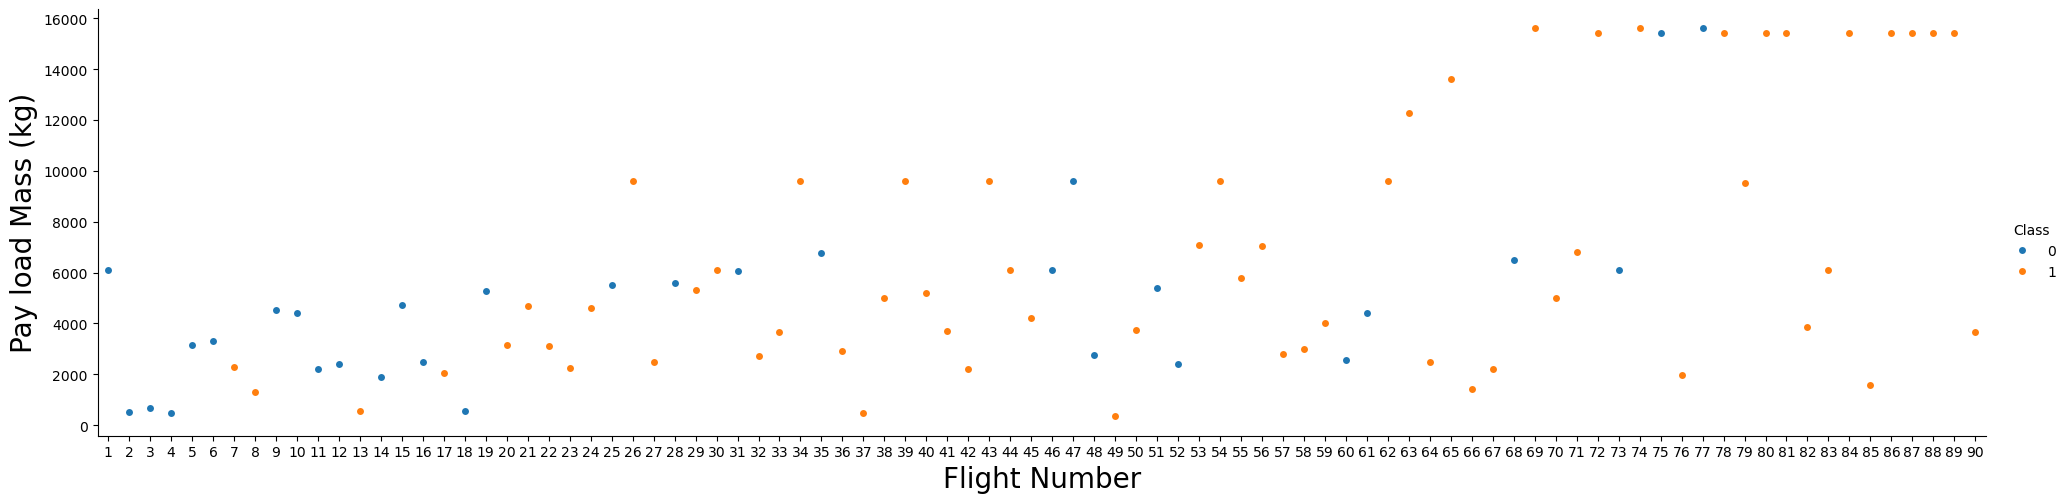

In [937]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 4)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

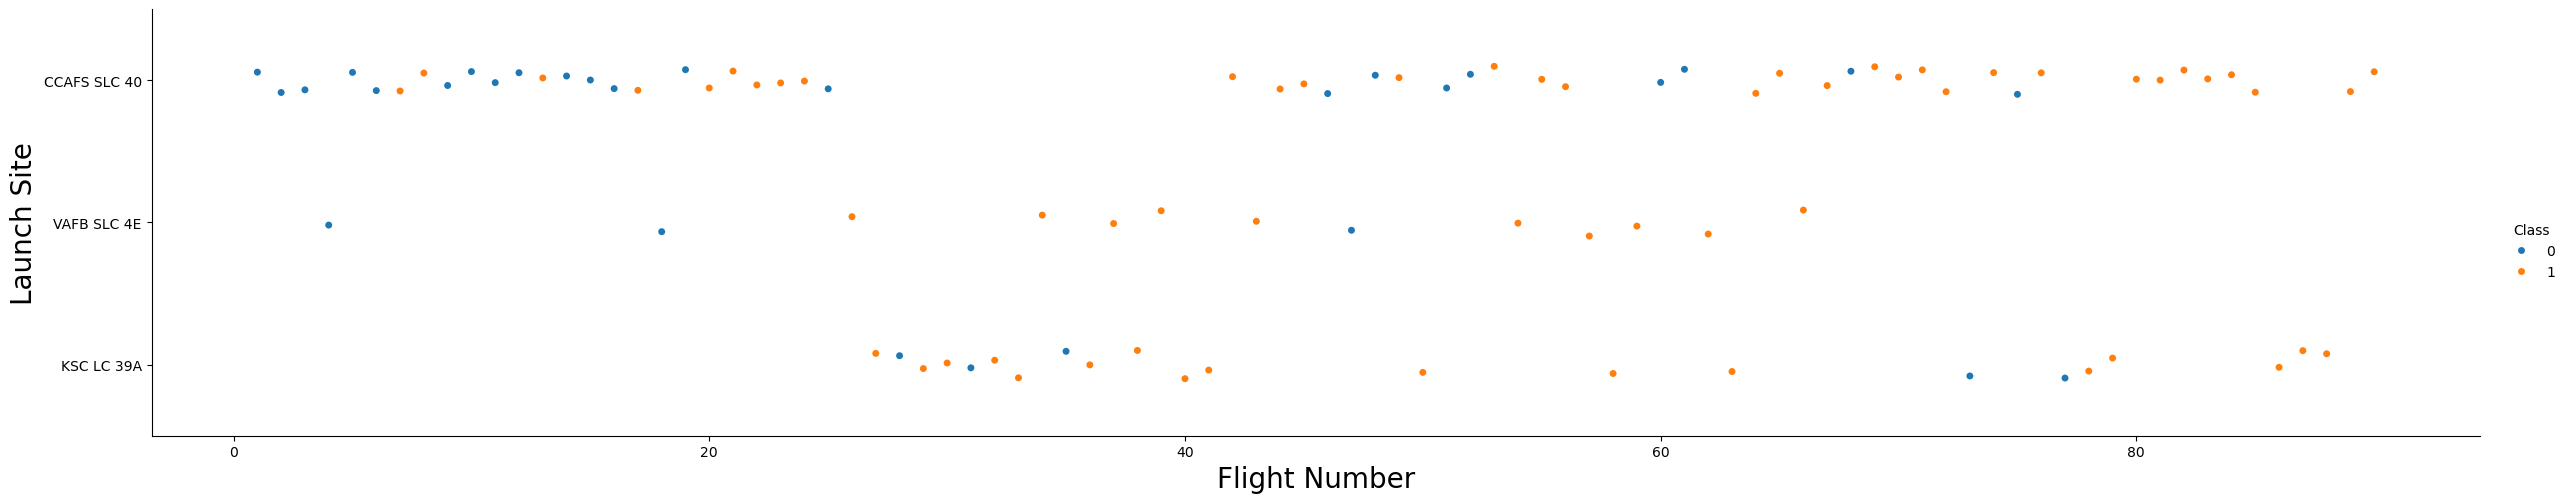

In [947]:
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.show()

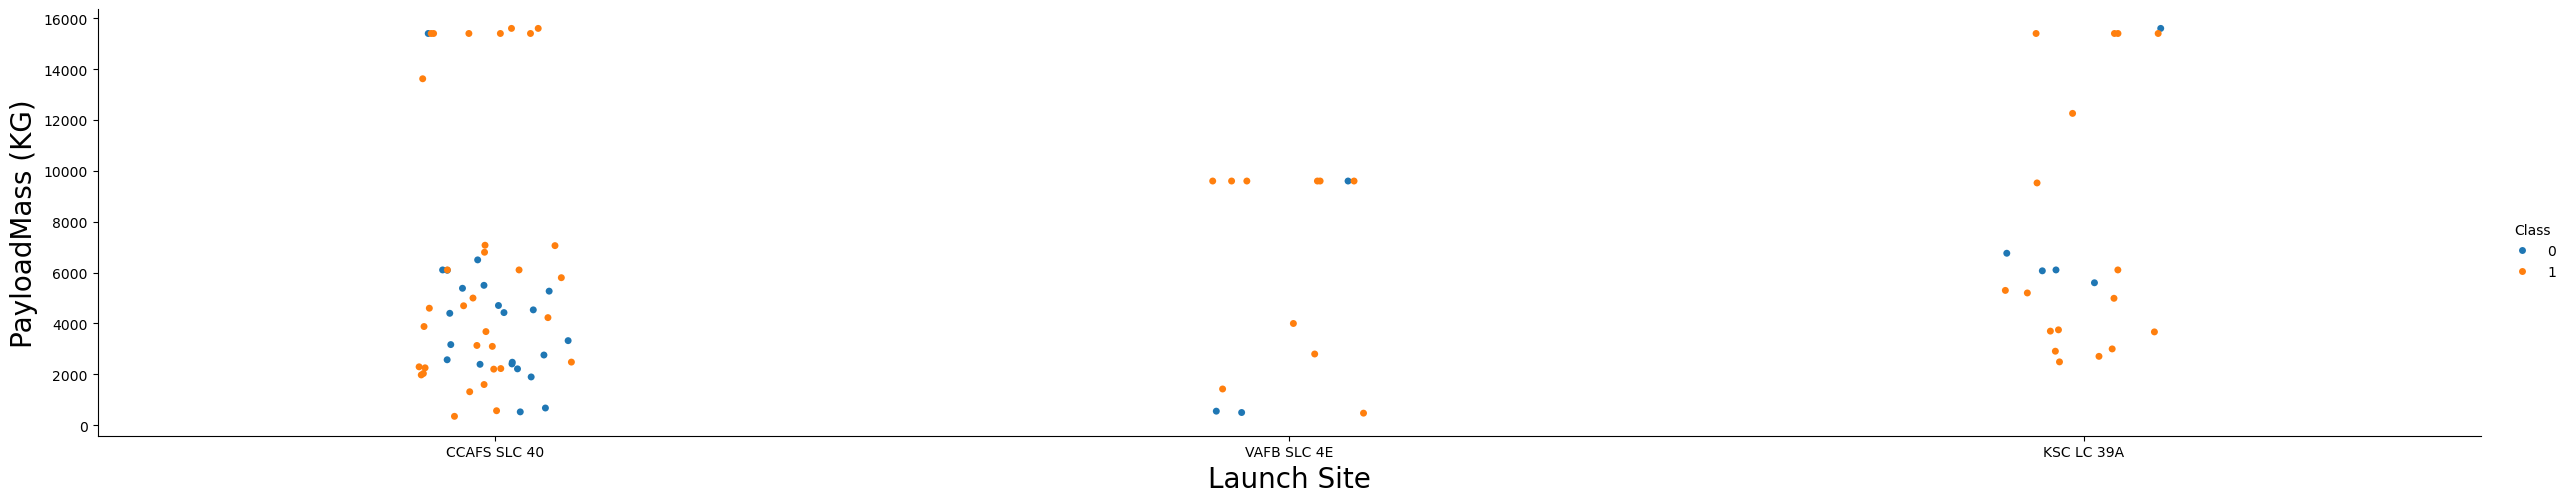

In [953]:
sns.catplot(y="PayloadMass", x="LaunchSite", hue="Class", data=df, aspect = 5)
plt.ylabel("PayloadMass (KG)",fontsize=20)
plt.xlabel("Launch Site",fontsize=20)
plt.show()

<Axes: xlabel='Orbit', ylabel='Class'>

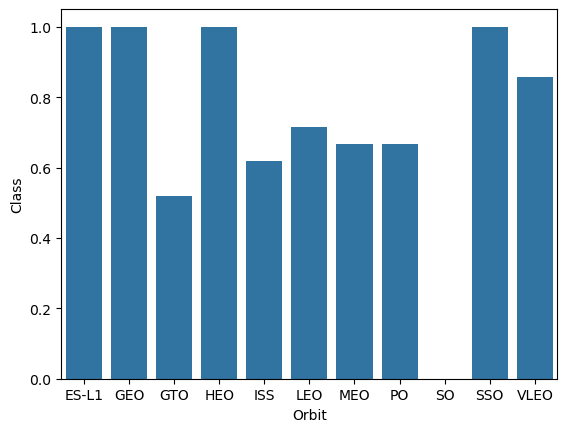

In [959]:
sns.barplot(df.groupby('Orbit')['Class'].mean())

Text(30.961191666666664, 0.5, 'Orbit')

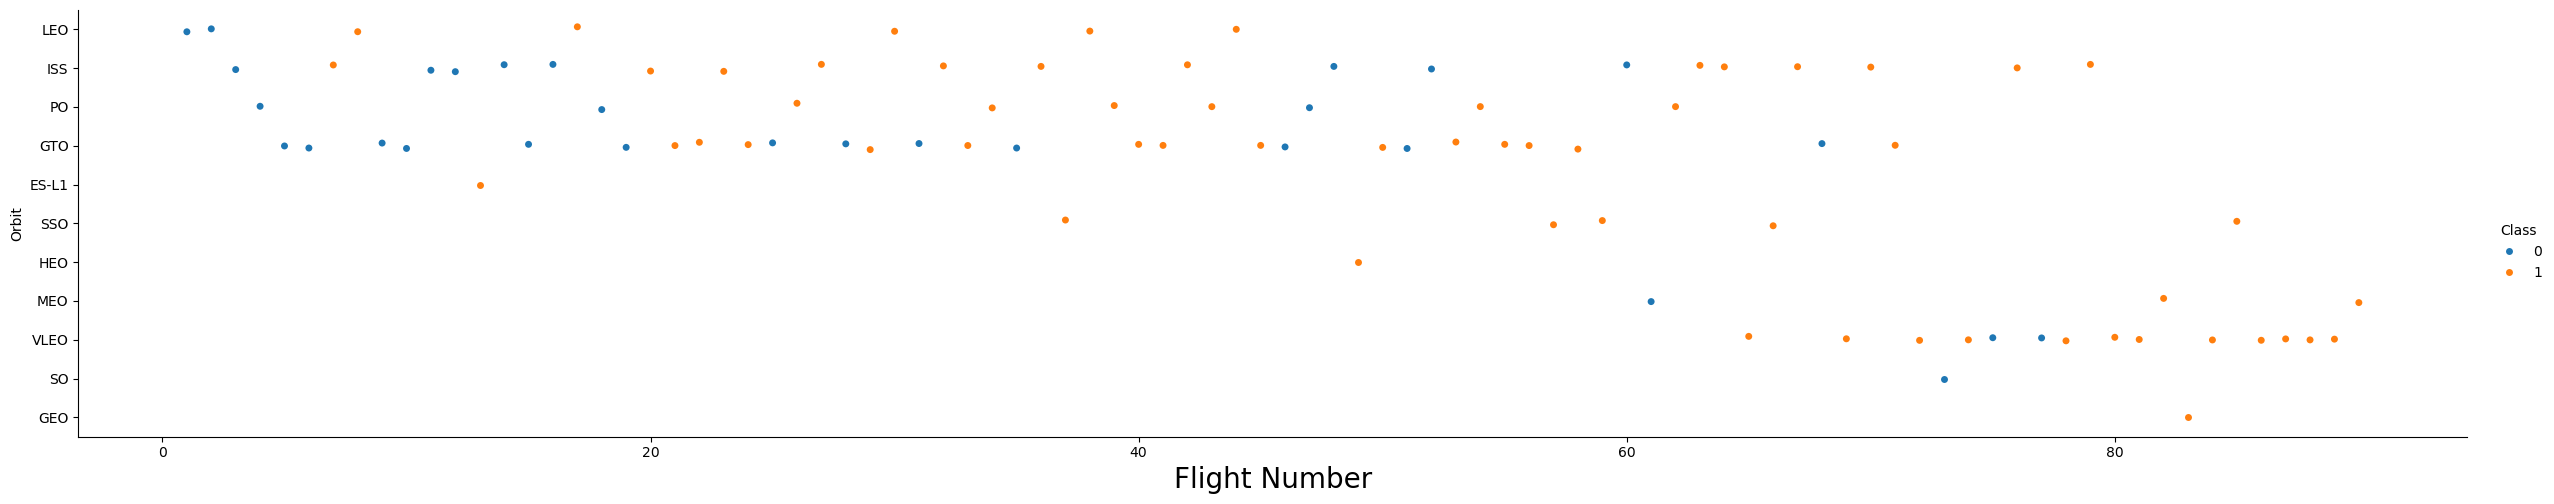

In [965]:
sns.catplot(x="FlightNumber", y="Orbit", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel('Orbit')

Text(0.5, 28.999999999999986, 'Orbit')

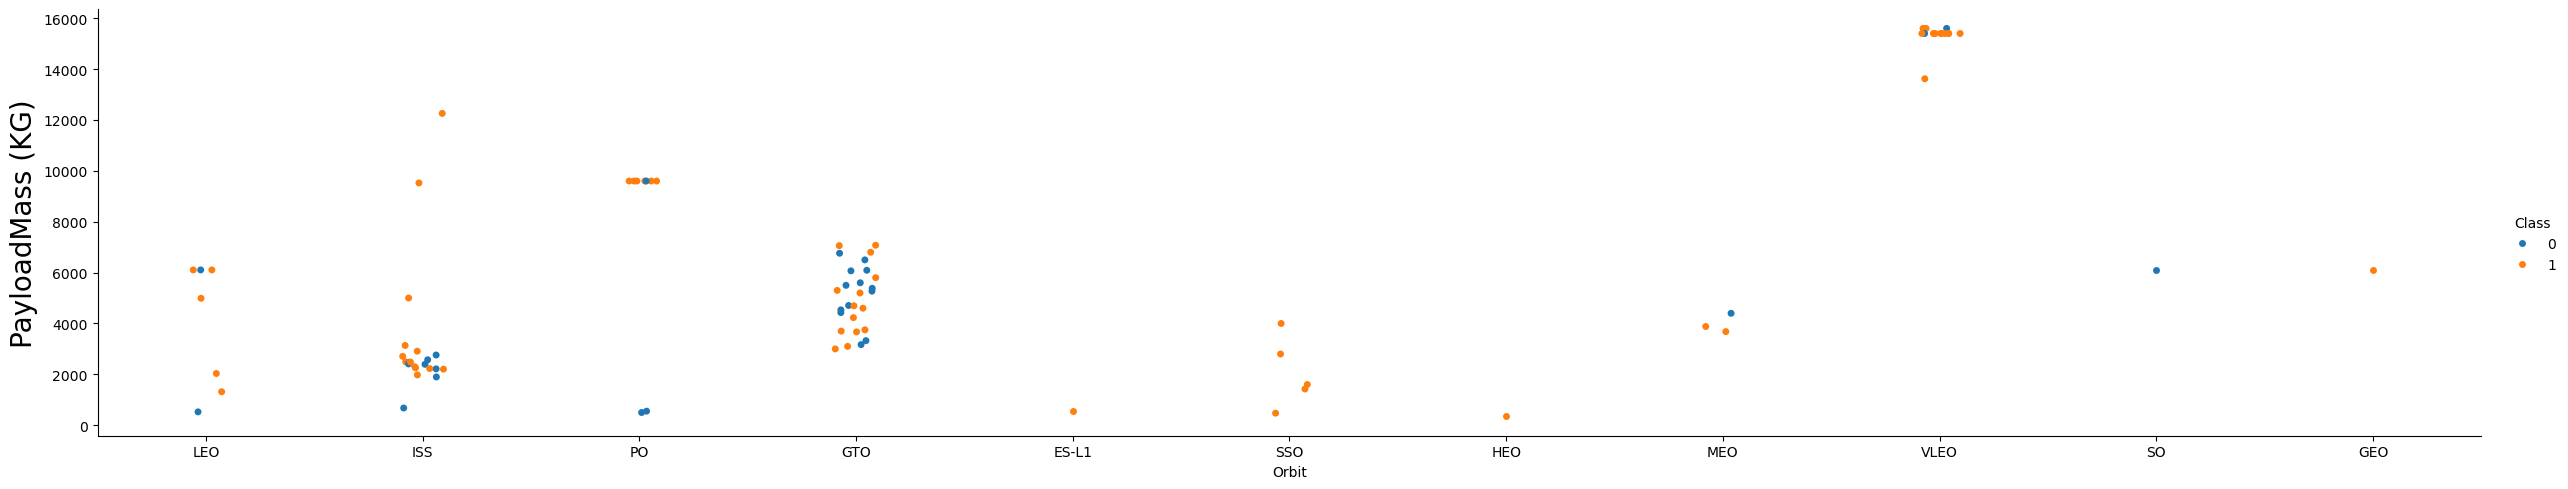

In [967]:
sns.catplot(y="PayloadMass", x="Orbit", hue="Class", data=df, aspect = 5)
plt.ylabel("PayloadMass (KG)",fontsize=20)
plt.xlabel('Orbit')

In [969]:
# A function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [973]:
a = df.groupby('Date')['Class'].sum()

In [977]:
a.values

array([ 0,  0,  0,  2,  2,  5, 15, 11,  9, 16])

<Axes: xlabel='Date'>

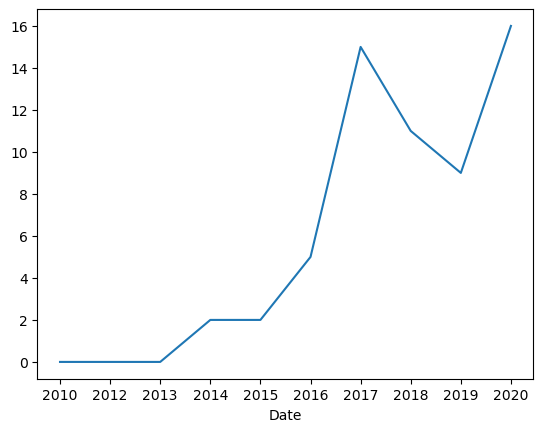

In [987]:
sns.lineplot(x = a.index, y = a.values)

In [989]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


In [995]:
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

In [997]:
features_one_hot

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86,15400.000000,2,True,True,True,5.0,2,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,F

In [999]:
features_one_hot = features_one_hot.astype('float64')

In [1001]:
features_one_hot

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,1.0,1.0,1.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
86,87.0,15400.000000,3.0,1.0,1.0,1.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
87,88.0,15400.000000,6.0,1.0,1.0,1.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [1003]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)

In [1005]:
import folium

# Example DataFrame (assuming it contains the following columns)
# df = pd.DataFrame({
#     'LaunchSite': ['CCAFS LC-40', 'VAFB SLC-4E', 'KSC LC-39A', 'CCAFS SLC-40'],
#     'Latitude': [28.562302, 34.632834, 28.573255, 28.561857],
#     'Longitude': [-80.577356, -120.610746, -80.651387, -80.577366]
# })

# Create a folium map centered at an average location (e.g., between all launch sites)
map_center = [df['Latitude'].mean(), df['Longitude'].mean()]
launch_map = folium.Map(location=map_center, zoom_start=5)

# Add markers for each launch site
for index, row in df.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['LaunchSite'],
    ).add_to(launch_map)

# Display the map
launch_map


In [1007]:
# Save map to an HTML file
launch_map.save("launch_sites_map.html")

In [1015]:

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv'

# Fetch the data from the URL
response = requests.get(URL)
response.raise_for_status()  # Check if the request was successful

# Read the CSV data into a DataFrame
df = pd.read_csv(pd.compat.StringIO(response.text))

# Display the first few rows of the DataFrame
print(df.head())


AttributeError: module 'pandas.compat' has no attribute 'StringIO'

In [1027]:


# URL to the CSV fi
URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv'

# Fetch the data
response = requests.get(URL)
response.raise_for_status()

# Read the CSV data into a DataFrame using StringIO
spacex_df = pd.read_csv(io.StringIO(response.text))

# Display the first few rows of the DataFrame
print(spacex_df.head())


   Flight Number        Date Time (UTC) Booster Version  Launch Site  \
0              1  2010-06-04   18:45:00  F9 v1.0  B0003  CCAFS LC-40   
1              2  2010-12-08   15:43:00  F9 v1.0  B0004  CCAFS LC-40   
2              3  2012-05-22    7:44:00  F9 v1.0  B0005  CCAFS LC-40   
3              4  2012-10-08    0:35:00  F9 v1.0  B0006  CCAFS LC-40   
4              5  2013-03-01   15:10:00  F9 v1.0  B0007  CCAFS LC-40   

                                                           Payload  \
0                             Dragon Spacecraft Qualification Unit   
1  Dragon demo flight C1, two CubeSats,  barrel of BrouÃ¨re cheese   
2                                           Dragon demo flight C2+   
3                                                     SpaceX CRS-1   
4                                                     SpaceX CRS-2   

   Payload Mass (kg)      Orbit         Customer        Landing Outcome  \
0                0.0        LEO           SpaceX  Failure   (parachute)

In [1029]:
# Create a folium map centered at an average location (e.g., between all launch sites)
map_center = [spacex_df['Lat'].mean(), spacex_df['Long'].mean()]
launch_map = folium.Map(location=map_center, zoom_start=5)

# Add markers for each launch site
for index, row in df.iterrows():
    folium.Marker(
        location=[row['Lat'], row['Long']],
        popup=row['Launch Site'],
    ).add_to(launch_map)

# Display the map in Jupyter Notebook or save it to an HTML file
launch_map

In [1031]:
# Select relevant sub-columns: `Launch Site`, `Lat(Latitude)`, `Long(Longitude)`, `class`
spacex_df = spacex_df[['Launch Site', 'Lat', 'Long', 'class']]
launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()
launch_sites_df = launch_sites_df[['Launch Site', 'Lat', 'Long']]
launch_sites_df

,Launch Site,Lat,Long
0,CCAFS LC-40,28.562302,-80.577356
1,CCAFS SLC-40,28.563197,-80.576820
2,KSC LC-39A,28.573255,-80.646895
3,VAFB SLC-4E,34.632834,-120.610745


In [1033]:
# Start location is NASA Johnson Space Center
nasa_coordinate = [29.559684888503615, -95.0830971930759]
site_map = folium.Map(location=nasa_coordinate, zoom_start=10)

In [1039]:
from folium.features import DivIcon

# Create a blue circle at NASA Johnson Space Center's coordinate with a popup label showing its name
circle = folium.Circle(nasa_coordinate, radius=1000, color='#d35400', fill=True).add_child(folium.Popup('NASA Johnson Space Center'))
# Create a blue circle at NASA Johnson Space Center's coordinate with a icon showing its name
marker = folium.map.Marker(
    nasa_coordinate,
    # Create an icon as a text label
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % 'NASA JSC',
        )
    )
site_map.add_child(circle)
site_map.add_child(marker)

In [1041]:
import folium

# Example DataFrame (replace with your actual DataFrame)
# df = pd.DataFrame({
#     'Launch Site': ['CCAFS LC-40', 'VAFB SLC-4E', 'KSC LC-39A', 'CCAFS SLC-40'],
#     'Lat': [28.562302, 34.632834, 28.573255, 28.561857],
#     'Long': [-80.577356, -120.610746, -80.651387, -80.577366]
# })

# Create a map centered around the average location of the launch sites
site_map = folium.Map(location=[launch_sites_df['Lat'].mean(), launch_sites_df['Long'].mean()], zoom_start=5)

# Add a Circle and Marker for each launch site
for index, row in df.iterrows():
    # Add a circle for each launch site
    folium.Circle(
        location=[row['Lat'], row['Long']],
        radius=1000,  # Radius in meters
        color='#d35400',
        fill=True,
        fill_color='#d35400'
    ).add_to(site_map)
    
    # Add a marker for each launch site
    folium.Marker(
        location=[row['Lat'], row['Long']],
        popup=row['Launch Site'],
        icon=folium.Icon(icon='rocket', prefix='fa')
    ).add_to(site_map)

# Display the map (in Jupyter Notebook) or save to an HTML file
site_map


In [1043]:
import folium
from folium.features import DivIcon

# Example DataFrame (replace with your actual DataFrame)
# df = pd.DataFrame({
#     'Launch Site': ['CCAFS LC-40', 'VAFB SLC-4E', 'KSC LC-39A', 'CCAFS SLC-40'],
#     'Lat': [28.562302, 34.632834, 28.573255, 28.561857],
#     'Long': [-80.577356, -120.610746, -80.651387, -80.577366]
# })

# Create a map centered around the average location of the launch sites
site_map = folium.Map(location=[launch_sites_df, zoom_start=5)

# Add a Circle and Marker for each launch site
for index, row in df.iterrows():
    # Add a circle for each launch site
    folium.Circle(
        location=[row['Lat'], row['Long']],
        radius=1000,  # Radius in meters
        color='#000000',
        fill=True,
        fill_color='#000000'
    ).add_child(folium.Popup(row['Launch Site'])).add_to(site_map)
    
    # Add a marker for each launch site
    folium.Marker(
        location=[row['Lat'], row['Long']],
        icon=DivIcon(
            icon_size=(20, 20),
            icon_anchor=(0, 0),
            html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % row['Launch Site'],
        )
    ).add_to(site_map)

# Display the map (in Jupyter Notebook) or save to an HTML file
site_map


In [1045]:
# Coordinate to center the map around the launch sites
center_coordinate = [28.562302, -80.577356]  # Centered around CCAFS LC-40

# Initialize the map
site_map = folium.Map(location=center_coordinate, zoom_start=5)


In [1051]:
# Define the icon colors based on the outcome
icon_colors = {
    'Success': 'green',
    'Failed': 'red'
}

# Add a marker for each launch outcome
for index, row in df.iterrows():
    folium.Marker(
        location=[row['Lat'], row['Long']],
        popup=row['Launch Site'] + ": " + row['Class'],
        icon=folium.Icon(color=icon_colors[row['Class']])
    ).add_to(site_map)

# Display the map
site_map


KeyError: 'Class'

In [1053]:
# Group by 'Launch Site' to calculate success rates
success_rate_df = spacex_df.groupby('Launch Site').agg(
    Total_Launches=('class', 'count'),
    Successful_Launches=('class', 'sum')
).reset_index()

# Calculate the success rate
success_rate_df['Success_Rate'] = success_rate_df['Successful_Launches'] / success_rate_df['Total_Launches']


In [1055]:
# Merge the success rate data with the original DataFrame to get coordinates
launch_site_df = spacex_df[['Launch Site', 'Lat', 'Long']].drop_duplicates()
launch_site_success_df = pd.merge(launch_site_df, success_rate_df, on='Launch Site')


In [1057]:
# Merge the success rate data with the original DataFrame to get coordinates
launch_site_df = spacex_df[['Launch Site', 'Lat', 'Long']].drop_duplicates()
launch_site_success_df = pd.merge(launch_site_df, success_rate_df, on='Launch Site')


In [1059]:

# Center the map around the average coordinates of the launch sites
center_coordinate = [launch_site_success_df['Lat'].mean(), launch_site_success_df['Long'].mean()]
site_map = folium.Map(location=center_coordinate, zoom_start=5)


In [1061]:
# Define a color mapping based on success rate
def get_color(success_rate):
    if success_rate >= 0.8:
        return 'green'
    elif 0.5 <= success_rate < 0.8:
        return 'orange'
    else:
        return 'red'

# Add circles and markers for each launch site
for index, row in launch_site_success_df.iterrows():
    folium.Circle(
        location=[row['Lat'], row['Long']],
        radius=row['Total_Launches'] * 1000,  # Radius proportional to the number of launches
        color=get_color(row['Success_Rate']),
        fill=True,
        fill_color=get_color(row['Success_Rate']),
        fill_opacity=0.6
    ).add_child(folium.Popup(f"{row['Launch Site']}<br>Success Rate: {row['Success_Rate']:.2%}")).add_to(site_map)
    
    folium.Marker(
        location=[row['Lat'], row['Long']],
        icon=folium.Icon(color=get_color(row['Success_Rate'])),
        popup=f"{row['Launch Site']}<br>Success Rate: {row['Success_Rate']:.2%}<br>Total Launches: {row['Total_Launches']}"
    ).add_to(site_map)

# Display the map
site_map


In [1063]:
spacex_df.tail(10)

,Launch Site,Lat,Long,class
46,KSC LC-39A,28.573255,-80.646895,1
47,KSC LC-39A,28.573255,-80.646895,1
48,KSC LC-39A,28.573255,-80.646895,1
49,CCAFS SLC-40,28.563197,-80.576820,1
50,CCAFS SLC-40,28.563197,-80.576820,1
51,CCAFS SLC-40,28.563197,-80.576820,0
52,CCAFS SLC-40,28.563197,-80.576820,0
53,CCAFS SLC-40,28.563197,-80.576820,0
54,CCAFS SLC-40,28.563197,-80.576820,1
55,CCAFS SLC-40,28.563197,-80.576820,0


In [1067]:
from folium.plugins import MarkerCluster

marker_cluster = MarkerCluster()


In [1069]:
def get_marker_color(launch_class):
    """
    Function to return marker color based on the launch class.
    Green for success (class=1), red for failure (class=0).
    """
    if launch_class == 1:
        return 'green'
    else:
        return 'red'


In [1073]:
import folium
from folium.plugins import MarkerCluster

# Initialize the map
center_coordinate = [spacex_df['Lat'].mean(), spacex_df['Long'].mean()]
site_map = folium.Map(location=center_coordinate, zoom_start=5)

# Create a MarkerCluster object
marker_cluster = MarkerCluster().add_to(site_map)

# Add markers to the map
for index, row in spacex_df.iterrows():
    marker_color = get_marker_color(row['class'])
    
    # Add the marker to the MarkerCluster
    folium.Marker(
        location=[row['Lat'], row['Long']],
        popup=f"Launch Site: {row['Launch Site']}<br>Outcome: {'Success' if row['class'] == 1 else 'Failed'}",
        icon=folium.Icon(color=marker_color)
    ).add_to(marker_cluster)

# Display the map (if using Jupyter Notebook)
site_map

# Save the map to an HTML file (optional)
#site_map.save("launch_records_map.html")


In [1075]:
import math

def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance in kilometers between two points
    on the Earth (specified in decimal degrees)
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.asin(math.sqrt(a))
    r = 6371  # Radius of the Earth in kilometers
    return c * r


In [1079]:
# Example proximities DataFrame
proximities_df = pd.DataFrame({
    'Proximity': ['City A', 'City B', 'Landmark C'],
    'Lat': [28.563, 28.574, 34.635],
    'Long': [-80.577, -80.648, -120.611]
})

# Choose a specific launch site (example: CCAFS LC-40)
launch_site = spacex_df[spacex_df['Launch Site'] == 'CCAFS LC-40'].iloc[0]

# Calculate distances to each proximity
proximities_df['Distance (km)'] = proximities_df.apply(
    lambda row: haversine(launch_site['Lat'], launch_site['Long'], row['Lat'], row['Long']),
    axis=1
)

# Display the distances
print(proximities_df)


    Proximity     Lat     Long  Distance (km)
0      City A  28.563  -80.577       0.085068
1      City B  28.574  -80.648       7.020379
2  Landmark C  34.635 -120.611    3825.858786


In [1083]:
from folium.plugins import MousePosition

# Add Mouse Position to get the coordinate (Lat, Long) for a mouse over on the map
formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter,
)

site_map.add_child(mouse_position)
site_map

In [1085]:
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    # approximate radius of earth in km
    R = 6373.0

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance